# 02 : Dimensionality Reduction (PCA & LDA)
### Phase 5: Customer Split & High-Value Labeling · Phase 6: Standardization, PCA, LDA · Phase 4.4: Representation Comparison

---

**Project pipeline (this notebook is stage 2 of 5):**

| Stage | Notebook | Purpose |
|---|---|---|
| 1 | `01_data_preprocessing.ipynb` | Load raw data, clean, engineer customer-level features |
| 2 | **`02_pca_lda.ipynb`** ⬅ *you are here* | Split customers, label high-value accounts, reduce dimensionality (PCA/LDA), benchmark representations |
| 3 | `03_classification.ipynb` | Classification modeling |
| 4 | `04_regression.ipynb` | Regression modeling |
| 5 | `05_qlearning_dqn.ipynb` | Reinforcement learning (Q-learning / DQN) |

**Input:** `../data/customer_features.csv` — one row per customer (RFM + Product Diversity + Avg. Spend + 5 category-spend-% columns), produced at the end of `01_data_preprocessing.ipynb`.

**What this notebook does, in order:**

| Phase | What it does |
|---|---|
| **Phase 5.1** | Split customers into train/validation/test (80/10/10), by **customer**, with a fixed seed — no customer's data ever appears in more than one split |
| **Phase 5.2** | Define a binary `HighValue` label using an 80th-percentile spend threshold computed **only from the training set** (to avoid leakage) |
| **Phase 6.1** | Standardize the 5 category-spend-% features (fit **only** on training data) |
| **Phase 6.2** | PCA — find the minimum number of components that explain ≥90% of variance |
| **Phase 6.3** | LDA — project onto the single linear axis that best separates High-Value vs. Low-Value customers |
| **Phase 4.4** | Train an identical Logistic Regression classifier on each representation (raw / PCA / LDA) and compare downstream performance |
| **Save** | Persist the split, labels, and reduced representations to disk for `03_classification.ipynb` |

> 💡 **How to use this notebook:** run cells top-to-bottom. Every code cell has markdown before it explaining *what/why*, and — for the more consequential steps — a **before/after check** (a table, a shape comparison, or a plot) immediately after, so you can confirm the transformation did what it was supposed to before moving on.

> ⚠️ **Why the strict train/val/test discipline matters here:** every statistic used to transform data — the 80th-percentile threshold, the standardization mean/std, the PCA/LDA axes — is fit **only on the training set**, then *applied* (never re-fit) to validation and test. If you accidentally fit any of these on the full dataset, information from the test set "leaks" into training, and every downstream accuracy number in `03_classification.ipynb`/`04_regression.ipynb` becomes optimistic and untrustworthy. Watch for this pattern (`.fit(train_df[...])` then `.transform(val_df[...])` / `.transform(test_df[...])`) throughout.

## 📦 Prerequisites

- Output of `01_data_preprocessing.ipynb`: `../data/customer_features.csv`
- `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`

In [1]:
import os
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Configure plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

print(f"pandas version      : {pd.__version__}")
print(f"numpy version       : {np.__version__}")
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

pandas version      : 2.3.3
numpy version       : 2.3.5
scikit-learn version: 1.7.2


## Loading the Engineered Feature Table (and Profiling it — "Before" State)

We load `customer_features.csv` from `01_data_preprocessing.ipynb`, and — before doing *anything* to it — record its **"before" shape and summary statistics**. This gives us a baseline to compare against once we've split, labeled, scaled, and reduced it, so every later "after" table in this notebook has something concrete to be checked against.

In [2]:
# ==========================================
# Load preprocessed customer-level feature matrix
# ==========================================
data_path = "../data/customer_features.csv"
if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Missing source data at: {data_path}\n"
        f"Run 01_data_preprocessing.ipynb first -- it produces this file as its final output."
    )

customer_features = pd.read_csv(data_path, index_col="CustomerID")

print("=== BEFORE: customer_features (as loaded) ===")
print(f"Shape   : {customer_features.shape}")
print(f"Columns : {customer_features.columns.tolist()}")
print(f"\nMissing values per column:\n{customer_features.isnull().sum()}")
customer_features.head()

=== BEFORE: customer_features (as loaded) ===
Shape   : (3616, 12)
Columns : ['Frequency', 'Monetary', 'ProductDiversity', 'Recency', 'AvgSpendPerTxn', 'Decorations_Pct', 'Gadgets_Pct', 'Homeware_Pct', 'Kitchenware_Pct', 'Other_Pct', 'Stationery_Pct', 'NextQuarterSpend']

Missing values per column:
Frequency           0
Monetary            0
ProductDiversity    0
Recency             0
AvgSpendPerTxn      0
Decorations_Pct     0
Gadgets_Pct         0
Homeware_Pct        0
Kitchenware_Pct     0
Other_Pct           0
Stationery_Pct      0
NextQuarterSpend    0
dtype: int64


,Frequency,Monetary,ProductDiversity,Recency,AvgSpendPerTxn,Decorations_Pct,Gadgets_Pct,Homeware_Pct,Kitchenware_Pct,Other_Pct,Stationery_Pct,NextQuarterSpend
CustomerID,,,,,,,,,,,,
12346,1,77183.60,1,256,77183.600000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.00
12347,5,2790.86,82,60,558.172000,0.000000,17.340891,1.461915,11.860143,57.566485,11.770565,1519.14
12348,4,1797.24,22,6,449.310000,3.538759,0.000000,0.000000,15.023035,58.402884,23.035321,0.00
12350,1,334.40,17,240,334.400000,0.000000,0.000000,0.000000,11.842105,88.157895,0.000000,0.00
12352,7,2194.31,47,3,313.472857,1.483382,5.550720,5.232169,14.603680,72.678883,0.451167,311.73


In [3]:
customer_features.describe().round(2)

,Frequency,Monetary,ProductDiversity,Recency,AvgSpendPerTxn,Decorations_Pct,Gadgets_Pct,Homeware_Pct,Kitchenware_Pct,Other_Pct,Stationery_Pct,NextQuarterSpend
count,3616.00,3616.00,3616.00,3616.00,3616.00,3616.00,3616.00,3616.00,3616.00,3616.00,3616.00,3616.00
mean,3.64,1712.41,52.22,92.78,407.96,6.40,7.32,6.53,11.46,61.98,6.31,639.66
std,6.12,7024.62,72.24,86.84,1378.10,11.00,12.42,9.66,13.66,20.93,9.47,3918.79
min,1.00,2.90,1.00,1.00,2.90,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,284.03,14.00,19.00,175.25,0.00,0.00,0.00,1.61,50.64,0.00,0.00
50%,2.00,599.83,30.50,64.00,294.50,2.42,3.13,3.76,8.26,63.45,3.48,69.06
75%,4.00,1440.90,65.00,148.00,431.43,8.69,9.45,8.98,15.95,75.04,8.55,521.21
max,139.00,203106.64,1474.00,304.00,77183.60,100.00,100.00,100.00,100.00,100.00,100.00,168469.60


### 🔍 Reading this baseline
- Expect **zero missing values** — `01_data_preprocessing.ipynb` already guarantees this (it's part of that notebook's final checkpoint).
- `Monetary`, `Frequency`, `Recency`, `AvgSpendPerTxn`, `ProductDiversity` are all on **very different scales** (e.g. `Recency` in days vs. `Monetary` in currency units) — this is exactly why the PCA/LDA input in Phase 6 uses only the 5 **already-comparable percentage** columns rather than these raw-scale columns directly.
- The `*_Pct` columns should each individually range `0–100`, and (per `01`'s own checkpoint) sum to ~100% per customer.

---
# Phase 5 — Customer Split and High-Value Label

## 5.1 Deterministic Customer-Level Split

**Rule:** split at the **customer** level (not the transaction level — that split already happened implicitly, since `customer_features` is already one row per customer) into **80% train / 10% validation / 10% test**, using a fixed random seed (`42`) so the split is exactly reproducible.

### Why split at the customer level at all?
Because `customer_features` is *already* customer-grain (one row per `CustomerID`), a plain `train_test_split` on its rows automatically guarantees no customer's data leaks across splits — there's only ever one row per customer to begin with. The real leakage risk this design prevents is a **different, more subtle mistake**: splitting the *transaction-level* table directly, which could put two invoices from the *same customer* into different splits, letting the model implicitly "see" a customer's behavior during training even when evaluating on a supposedly-unseen test invoice. Working from `customer_features` sidesteps that risk entirely.

### Why 80/10/10, and why two calls to `train_test_split`?
`train_test_split` only splits into two groups at a time. To get three groups, we call it twice: first peel off 80% train vs. 20% "temp," then split that 20% "temp" group evenly in half (`test_size=0.50`) to get 10%/10% validation and test.

In [4]:
# ==========================================
# Phase 5.1: Deterministic 80/10/10 customer-level split
# ==========================================
ids = customer_features.index.to_numpy()

train_ids, temp_ids = train_test_split(ids, test_size=0.20, random_state=42)
val_ids, test_ids   = train_test_split(temp_ids, test_size=0.50, random_state=42)

train_df = customer_features.loc[train_ids].copy()
val_df   = customer_features.loc[val_ids].copy()
test_df  = customer_features.loc[test_ids].copy()

print("=== TEST CHECK T5.1: DATA VOLUME DISPERSION ===")
print(f"Total input client records : {len(ids)}")
print(f"Training set cohort count  : {train_df.shape[0]} (~80%)")
print(f"Validation set cohort count: {val_df.shape[0]} (~10%)")
print(f"Testing set cohort count   : {test_df.shape[0]} (~10%)")

# Check for zero overlap to ensure zero leakage
assert len(set(train_ids).intersection(set(val_ids))) == 0, "Leakage detected between train and val!"
assert len(set(train_ids).intersection(set(test_ids))) == 0, "Leakage detected between train and test!"
assert len(set(val_ids).intersection(set(test_ids))) == 0, "Leakage detected between val and test!"
assert len(train_ids) + len(val_ids) + len(test_ids) == len(ids), "Split sizes don't sum to the total!"
print("\nVerification Status: Mutually exclusive subsets verified successfully; row counts sum to total.")

=== TEST CHECK T5.1: DATA VOLUME DISPERSION ===
Total input client records : 3616
Training set cohort count  : 2892 (~80%)
Validation set cohort count: 362 (~10%)
Testing set cohort count   : 362 (~10%)

Verification Status: Mutually exclusive subsets verified successfully; row counts sum to total.


### 🔍 Before/After Check — Split Summary Table & Visual

A table is the precise version of "did the split work"; a bar chart makes the ~80/10/10 proportions immediately visible at a glance. We build both.

     Split  Customer Count  Percent of Total
     Train            2892             79.98
Validation             362             10.01
      Test             362             10.01


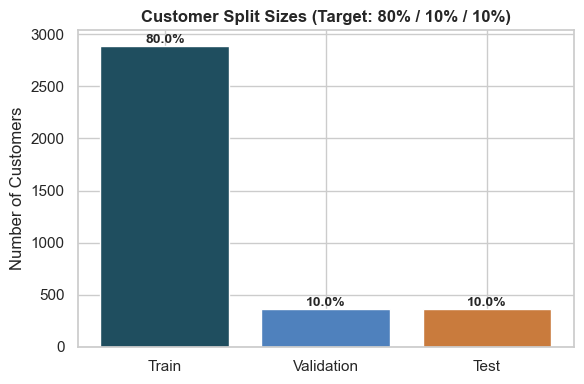

In [5]:
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Customer Count": [len(train_ids), len(val_ids), len(test_ids)],
})
split_summary["Percent of Total"] = (split_summary["Customer Count"] / len(ids) * 100).round(2)
print(split_summary.to_string(index=False))

plt.figure(figsize=(6, 4))
bars = plt.bar(split_summary["Split"], split_summary["Customer Count"],
                color=["#1F4E5F", "#4F81BD", "#C97B3D"])
for bar, pct in zip(bars, split_summary["Percent of Total"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
              f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.title("Customer Split Sizes (Target: 80% / 10% / 10%)", fontsize=12, fontweight="bold")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 5.2 High-Value Target Label Assignment

**Rule:** a customer is labeled `HighValue = 1` if their `Monetary` value is at or above the **80th percentile of `Monetary`, computed only on the training set**. That exact threshold (a single number) is then reused — never recomputed — to label validation and test customers.

### Why compute the threshold from training data only?
If we computed the 80th percentile from the *full* dataset (train+val+test combined), the threshold itself would be silently informed by validation/test customers' spending — meaning the "unseen" test set would have influenced how we defined the very label we're about to evaluate against. That's a textbook **information leakage** bug: it can make validation/test metrics look better than they'd be on truly new customers. Computing the threshold from **training data only**, then applying that fixed number everywhere, closes this leak.

In [6]:
# ==========================================
# Phase 5.2: 80th-percentile HighValue threshold (train-only)
# ==========================================
threshold = train_df["Monetary"].quantile(0.80)
print(f"=== TEST CHECK T5.2: TRAINING THRESHOLD DETERMINATION ===")
print(f"Static 80th Percentile Train Margin Cutoff: {threshold:.4f}\n")

# Apply labels uniformly across all splits (Test Check T5.3 and T5.4), using the SAME threshold
train_df["HighValue"] = (train_df["Monetary"] >= threshold).astype(int)
val_df["HighValue"]   = (val_df["Monetary"]   >= threshold).astype(int)
test_df["HighValue"]  = (test_df["Monetary"]  >= threshold).astype(int)

print("=== ASSIGNED TARGETS FREQUENCY REPORT ===")
print(f"Train class ratio      : {train_df['HighValue'].mean():.2%}")
print(f"Validation class ratio : {val_df['HighValue'].mean():.2%}")
print(f"Test class ratio       : {test_df['HighValue'].mean():.2%}")

=== TEST CHECK T5.2: TRAINING THRESHOLD DETERMINATION ===
Static 80th Percentile Train Margin Cutoff: 1754.9700

=== ASSIGNED TARGETS FREQUENCY REPORT ===
Train class ratio      : 20.02%
Validation class ratio : 20.17%
Test class ratio       : 22.38%


### 🔍 Before/After Check — Class Balance Table & Visual

By construction, the **training** ratio should land almost exactly at 20% (since the threshold *is* its 80th percentile). Validation and test ratios will be **close to but not exactly** 20% — that's expected and healthy: it tells us the training set's spending distribution is representative of the other splits, without those splits having influenced the threshold itself.

     Split  HighValue=1 Count  Total Count  HighValue %
     Train                579         2892        20.02
Validation                 73          362        20.17
      Test                 81          362        22.38


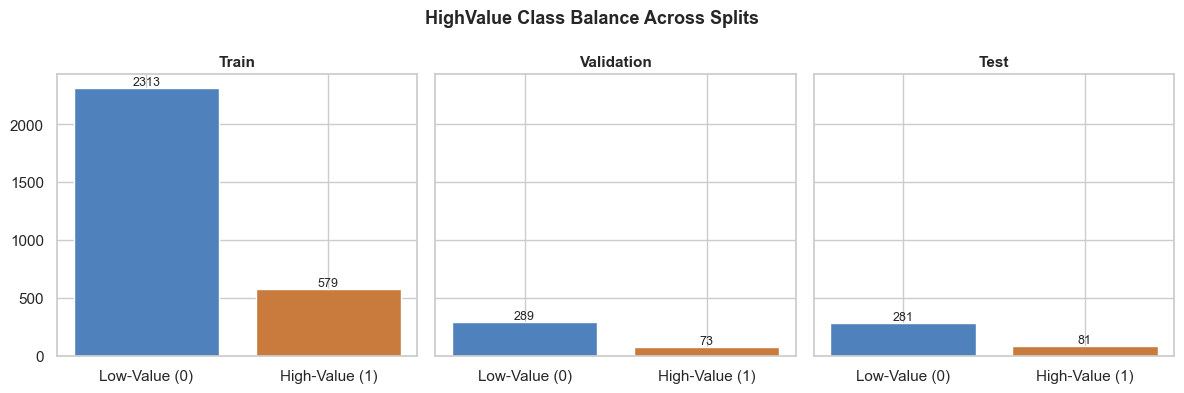

In [7]:
label_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "HighValue=1 Count": [train_df["HighValue"].sum(), val_df["HighValue"].sum(), test_df["HighValue"].sum()],
    "Total Count": [len(train_df), len(val_df), len(test_df)],
})
label_summary["HighValue %"] = (label_summary["HighValue=1 Count"] / label_summary["Total Count"] * 100).round(2)
print(label_summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (name, d) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
    counts = d["HighValue"].value_counts().sort_index()
    ax.bar(["Low-Value (0)", "High-Value (1)"], counts.values, color=["#4F81BD", "#C97B3D"])
    ax.set_title(name, fontsize=11, fontweight="bold")
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
fig.suptitle("HighValue Class Balance Across Splits", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## ✅ Phase 5 Checkpoint — Before vs. After Column Comparison

A quick, explicit table confirming exactly what Phase 5 added to the data, before we move into Phase 6.

In [8]:
phase5_checkpoint = pd.DataFrame({
    "State": ["Before Phase 5 (customer_features)", "After Phase 5 (train_df / val_df / test_df)"],
    "Row grain": ["1 row = 1 customer (all customers)", "1 row = 1 customer (split into 3 disjoint groups)"],
    "Columns": [len(customer_features.columns), len(train_df.columns)],
    "New column(s) added": ["--", "HighValue (binary label)"],
})
print(phase5_checkpoint.to_string(index=False))

assert "HighValue" in train_df.columns and "HighValue" in val_df.columns and "HighValue" in test_df.columns
assert set(train_df.columns) == set(val_df.columns) == set(test_df.columns)
print("\n\u2705 All three splits share an identical column schema; HighValue confirmed present in all three.")

                                      State                                         Row grain  Columns      New column(s) added
         Before Phase 5 (customer_features)                1 row = 1 customer (all customers)       12                       --
After Phase 5 (train_df / val_df / test_df) 1 row = 1 customer (split into 3 disjoint groups)       13 HighValue (binary label)

✅ All three splits share an identical column schema; HighValue confirmed present in all three.


---
# Phase 6 — PCA and LDA

## 6.1 Feature Standardization

**Which features feed PCA/LDA, and why only these 5?**
We use exactly the **5 category-spend-% columns** (`Homeware_Pct`, `Stationery_Pct`, `Gadgets_Pct`, `Decorations_Pct`, `Kitchenware_Pct`) — not `Recency`, `Frequency`, `Monetary`, etc. Those RFM-style columns are already being used directly as modeling features and as the basis for the `HighValue` label itself; feeding `Monetary` into PCA alongside the label it's used to define would be circular. The category-% columns instead capture a *different* signal — **shopping behavior/composition** — which is what we want PCA/LDA to summarize into fewer dimensions.

**Why standardize before PCA/LDA at all?**
PCA and LDA are both **distance/variance-based** methods — they find directions of maximum variance (PCA) or maximum class separation relative to within-class variance (LDA). If features are left on their raw scales, a column with a naturally larger numeric range dominates the result purely because of its scale, not because it's more informative. Standardizing every column to mean 0, variance 1 puts all 5 features on equal footing before either method looks at them.

**Why fit the scaler on `train_df` only?**
Same leakage principle as the threshold: `StandardScaler` learns a mean and standard deviation from whatever data it's `.fit()` on. Fitting on the full dataset would let validation/test statistics quietly influence the transformation applied to *all* three splits. We fit on `train_df` only, then `.transform()` (never re-fit) on `val_df` and `test_df`.

In [9]:
# ==========================================
# Phase 6.1: Standardize category-spend-% features (train-only fit)
# ==========================================
cat_cols = ["Homeware_Pct", "Stationery_Pct", "Gadgets_Pct", "Decorations_Pct", "Kitchenware_Pct"]

print("=== BEFORE standardization (train_df[cat_cols].describe()) ===")
print(train_df[cat_cols].describe().round(2))

scaler = StandardScaler().fit(train_df[cat_cols])

X_train_scaled = scaler.transform(train_df[cat_cols])
X_val_scaled   = scaler.transform(val_df[cat_cols])
X_test_scaled  = scaler.transform(test_df[cat_cols])

# Assert mean is 0 and variance is 1 -- but ONLY on the training set (by construction);
# val/test are expected to be CLOSE but not exactly 0/1, since they weren't used to fit the scaler.
assert np.allclose(X_train_scaled.mean(axis=0), 0, atol=1e-7), "Standardization mean constraint failed!"
assert np.allclose(X_train_scaled.var(axis=0), 1, atol=1e-7), "Standardization variance constraint failed!"
print("\n\u2705 Feature scaling checks passed: Train mean == 0.0, Train variance == 1.0.")

print("\n=== AFTER standardization (train_df, as a DataFrame for readability) ===")
scaled_preview = pd.DataFrame(X_train_scaled, columns=cat_cols, index=train_df.index)
print(scaled_preview.describe().round(2))

=== BEFORE standardization (train_df[cat_cols].describe()) ===
       Homeware_Pct  Stationery_Pct  Gadgets_Pct  Decorations_Pct  \
count       2892.00         2892.00      2892.00          2892.00   
mean           6.59            6.18         7.19             6.44   
std            9.57            9.19        11.96            11.01   
min            0.00            0.00         0.00             0.00   
25%            0.00            0.00         0.00             0.00   
50%            3.77            3.34         3.22             2.38   
75%            9.10            8.44         9.47             8.83   
max          100.00          100.00       100.00           100.00   

       Kitchenware_Pct  
count          2892.00  
mean             11.47  
std              13.42  
min               0.00  
25%               1.81  
50%               8.37  
75%              15.81  
max             100.00  

✅ Feature scaling checks passed: Train mean == 0.0, Train variance == 1.0.

=== AFTER sta

### 🔍 Before/After Check — Distribution Shift Visual

Standardization *rescales* each column but never changes its *shape* (skew, outliers, multi-modality) — only PCA/LDA's downstream math cares about the rescaling, but it's worth seeing it directly: same relative distribution, now centered near 0 with comparable spread across all 5 columns.

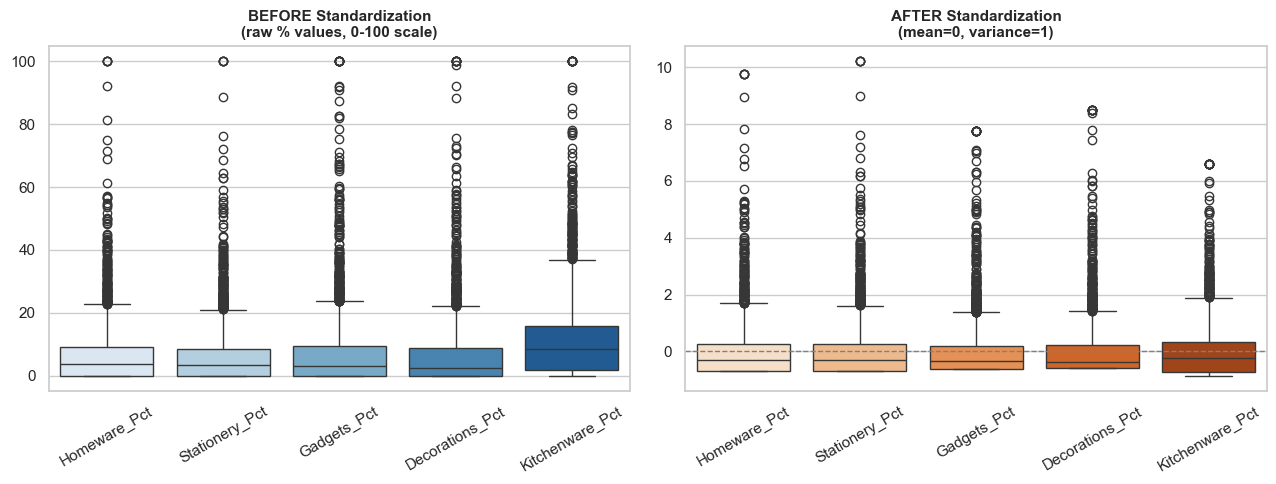

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=train_df[cat_cols], ax=axes[0], palette="Blues")
axes[0].set_title("BEFORE Standardization\n(raw % values, 0-100 scale)", fontsize=11, fontweight="bold")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=scaled_preview, ax=axes[1], palette="Oranges")
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("AFTER Standardization\n(mean=0, variance=1)", fontsize=11, fontweight="bold")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6.2 Principal Component Analysis (PCA)

**Goal:** find the smallest number of new, uncorrelated axes ("principal components") that together explain **≥90%** of the variance in the 5 standardized category-% features.

**Approach:**
1. Fit a *full* PCA (all 5 components) on the training data, purely to inspect how variance accumulates component-by-component.
2. Find the minimum component count `n_components` where the **cumulative** explained variance first crosses 90%.
3. Re-fit PCA with exactly that many components, and use it to transform train/val/test (fit on train only — same leakage discipline as before).

In [11]:
# ==========================================
# Phase 6.2: PCA -- explore full variance trace, then pick n_components
# ==========================================
pca_full = PCA().fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# --- New Variance Breakdown Display ---
print("--- PCA COMPONENT VARIANCE BREAKDOWN ---")
for i, (individual, cumulative) in enumerate(zip(pca_full.explained_variance_ratio_, cum_var), 1):
    print(f"PC{i}: Individual Variance = {individual:.4f} ({individual*100:.2f}%) | Cumulative Variance = {cumulative:.4f} ({cumulative*100:.2f}%)")
print("-" * 40)

print("\n=== TEST CHECK T6.1: TOTAL EXPLAINED TRACE COMPLIANCE ===")
print(f"Sum total of variance components: {sum(pca_full.explained_variance_ratio_):.6f}")
assert np.isclose(sum(pca_full.explained_variance_ratio_), 1.0), "Total components variance trace must equal 1.0!"

n_components = np.argmax(cum_var >= 0.90) + 1
print(f"\n=== TEST CHECK T6.2: OPTIMAL DIMENSION EXTRACT ===")
print(f"Selected Minimum Component Count (>=90% variance threshold): {n_components}")

pca = PCA(n_components=n_components).fit(X_train_scaled)
train_pcs = pca.transform(X_train_scaled)
val_pcs   = pca.transform(X_val_scaled)
test_pcs  = pca.transform(X_test_scaled)

--- PCA COMPONENT VARIANCE BREAKDOWN ---
PC1: Individual Variance = 0.2399 (23.99%) | Cumulative Variance = 0.2399 (23.99%)
PC2: Individual Variance = 0.2287 (22.87%) | Cumulative Variance = 0.4686 (46.86%)
PC3: Individual Variance = 0.2020 (20.20%) | Cumulative Variance = 0.6706 (67.06%)
PC4: Individual Variance = 0.1913 (19.13%) | Cumulative Variance = 0.8619 (86.19%)
PC5: Individual Variance = 0.1381 (13.81%) | Cumulative Variance = 1.0000 (100.00%)
----------------------------------------

=== TEST CHECK T6.1: TOTAL EXPLAINED TRACE COMPLIANCE ===
Sum total of variance components: 1.000000

=== TEST CHECK T6.2: OPTIMAL DIMENSION EXTRACT ===
Selected Minimum Component Count (>=90% variance threshold): 5


### 🔍 Graph 1 — Individual + Cumulative Explained Variance

The **bars** show how much variance *each individual* component captures on its own; the **line** shows the running total. The point where the line crosses the red 90% threshold is exactly `n_components`.

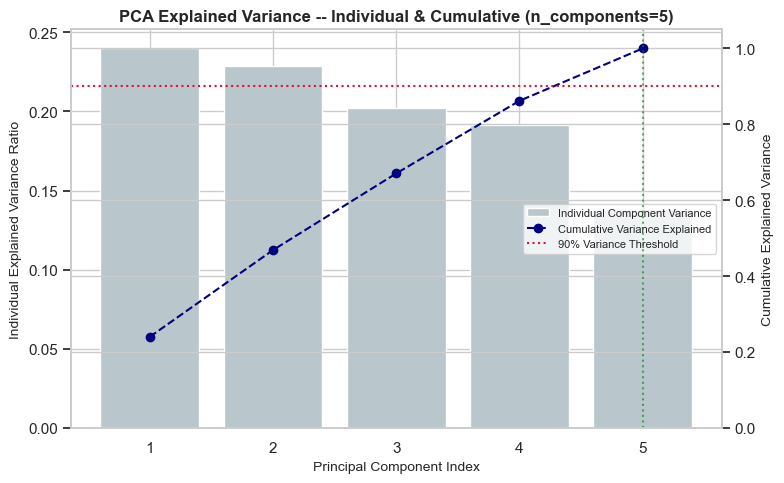

In [12]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(range(1, len(cum_var) + 1), pca_full.explained_variance_ratio_,
        color="#B9C7CC", label="Individual Component Variance")
ax1.set_xlabel("Principal Component Index", fontsize=10)
ax1.set_ylabel("Individual Explained Variance Ratio", fontsize=10)
ax1.set_xticks(range(1, len(cum_var) + 1))

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_var) + 1), cum_var, marker='o', ls='--', color='navy',
         label='Cumulative Variance Explained')
ax2.axhline(y=0.90, color='crimson', linestyle=':', label='90% Variance Threshold')
ax2.axvline(x=n_components, color='green', linestyle=':', alpha=0.6)
ax2.set_ylabel("Cumulative Explained Variance", fontsize=10)
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=8)

plt.title(f"PCA Explained Variance -- Individual & Cumulative (n_components={n_components})",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 Graph 2 — PCA Loadings Heatmap (What does each component actually *mean*?)

PCA components are abstract math constructs — this heatmap translates them back into business terms by showing how strongly each **original category-% feature** contributes (positively or negatively) to each retained component. A large positive/negative value means that feature dominates that component's direction.

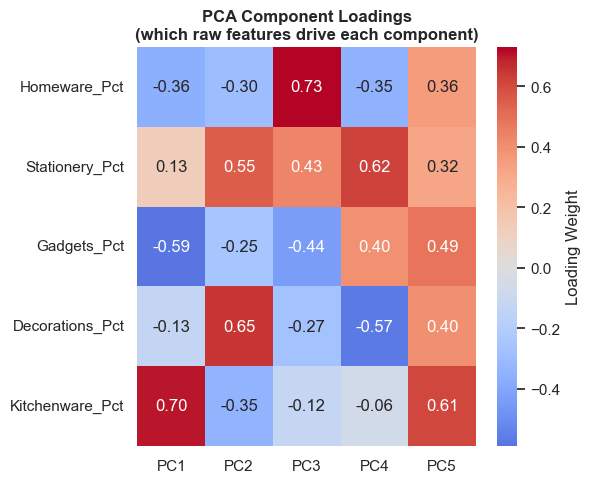

                   PC1    PC2    PC3    PC4    PC5
Homeware_Pct    -0.362 -0.300  0.729 -0.347  0.356
Stationery_Pct   0.127  0.553  0.431  0.624  0.322
Gadgets_Pct     -0.589 -0.251 -0.443  0.397  0.486
Decorations_Pct -0.129  0.649 -0.266 -0.573  0.403
Kitchenware_Pct  0.700 -0.347 -0.123 -0.065  0.609


In [13]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=cat_cols,
    columns=[f"PC{i+1}" for i in range(n_components)],
)

plt.figure(figsize=(6, 5))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"label": "Loading Weight"})
plt.title("PCA Component Loadings\n(which raw features drive each component)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(loadings.round(3).to_string())

### 🔍 Graph 3 — 2D Projection (PC1 vs. PC2), Colored by `HighValue`

If PC1/PC2 alone visually separate the two colors into distinguishable regions, that's a strong sign the category-spend pattern (not just total spend) correlates with customer value — worth knowing before we even get to LDA or classification.

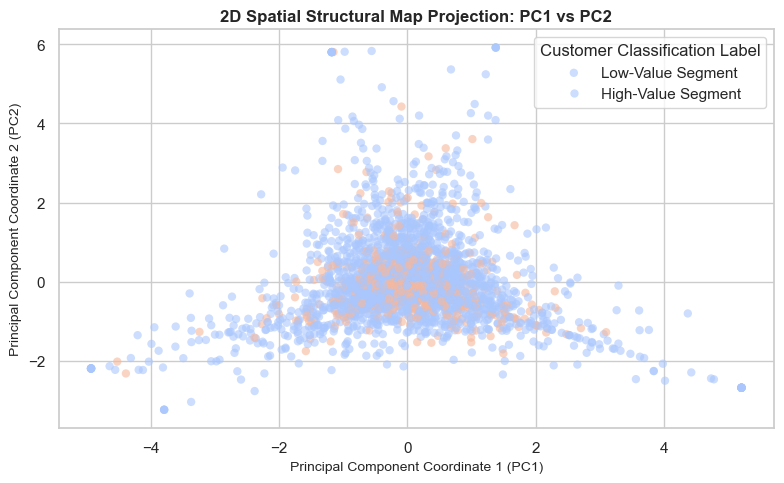

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=train_pcs[:, 0],
    y=train_pcs[:, 1],
    hue=train_df["HighValue"],
    palette="coolwarm",
    alpha=0.6,
    edgecolor='none'
)
plt.title("2D Spatial Structural Map Projection: PC1 vs PC2", fontsize=12, fontweight='bold')
plt.xlabel("Principal Component Coordinate 1 (PC1)", fontsize=10)
plt.ylabel("Principal Component Coordinate 2 (PC2)", fontsize=10)
plt.legend(title="Customer Classification Label", labels=["Low-Value Segment", "High-Value Segment"])
plt.tight_layout()
plt.show()

## 6.3 Linear Discriminant Analysis (LDA)

**How LDA differs from PCA:** PCA is **unsupervised** — it doesn't know about `HighValue` at all, and simply finds directions of maximum *variance*. LDA is **supervised** — it uses the `HighValue` label directly to find the direction that best *separates the two classes*.

**Why exactly 1 LDA component?** For a `C`-class classification problem, LDA can produce at most `C - 1` discriminant axes. Since `HighValue` is binary (`C = 2`), LDA is mathematically restricted to **exactly 1** axis — there's no "elbow" or threshold to choose here, unlike PCA's `n_components`.

=== TEST CHECK T6.3 & T6.4: STRUCTURAL COMPLIANCE ANALYSIS ===
Extracted Train LDA Matrix Transformed Shape: (2892, 1) (Matches expected 1 Component Dimension)
LDA Projection Weights Vector Shape Matrix  : (1, 5) (Matches expected 1 x 5 footprint)

--- LDA Loading Weights Distribution Table ---
        Feature  Coefficient Weight Value
    Gadgets_Pct                  0.011089
Kitchenware_Pct                 -0.011090
Decorations_Pct                 -0.082534
 Stationery_Pct                 -0.085485
   Homeware_Pct                 -0.196697


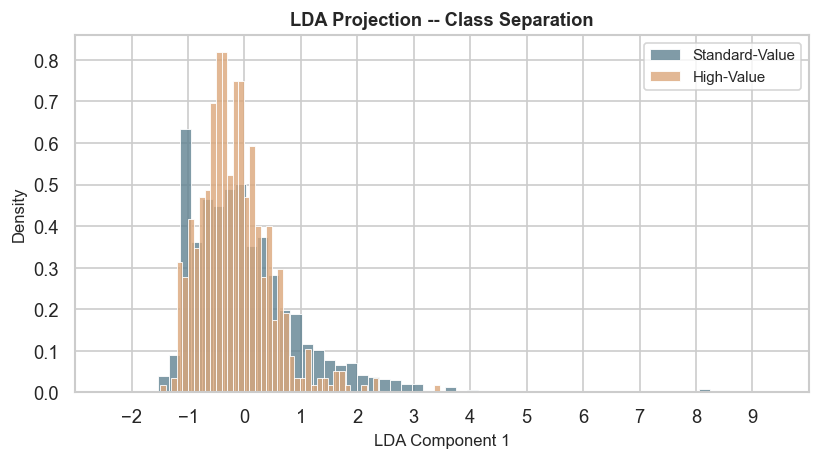

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ==========================================
# Phase 6.3: LDA -- single supervised discriminant axis
# ==========================================
lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit(X_train_scaled, train_df["HighValue"])

train_lda = lda.transform(X_train_scaled)
val_lda   = lda.transform(X_val_scaled)
test_lda  = lda.transform(X_test_scaled)

print("=== TEST CHECK T6.3 & T6.4: STRUCTURAL COMPLIANCE ANALYSIS ===")
print(f"Extracted Train LDA Matrix Transformed Shape: {train_lda.shape} (Matches expected 1 Component Dimension)")
print(f"LDA Projection Weights Vector Shape Matrix  : {lda.coef_.shape} (Matches expected 1 x 5 footprint)")

assert train_lda.shape[1] == 1, "LDA projection dimensionality cannot exceed 1 for binary classification targets!"
assert lda.coef_.shape == (1, 5), "LDA loading weight arrays must match input feature size!"

lda_weights = pd.DataFrame({
    'Feature': cat_cols,
    'Coefficient Weight Value': lda.coef_[0]
}).sort_values(by='Coefficient Weight Value', ascending=False)

print("\n--- LDA Loading Weights Distribution Table ---")
print(lda_weights.to_string(index=False))

# ==========================================
# Dynamic Visualization -- Class Separation
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4), dpi=120)

# Unpack data dynamically
lda_scores = train_lda.ravel()
labels = train_df["HighValue"].values

# Extract unique target labels and configure mapping properties
unique_classes = np.sort(np.unique(labels))
colors = ["#608291", "#DBA77B"]  # Muted Blue-Grey & Muted Peach
class_names = {0: "Standard-Value", 1: "High-Value"}

# Calculate optimal bin widths using Freedman-Diaconis rule without hardcoding
all_data_range = np.ptp(lda_scores)
q75, q25 = np.percentile(lda_scores, [75, 25])
iqr = q75 - q25
bin_width = 2 * iqr / (len(lda_scores) ** (1/3)) if iqr > 0 else 0.5
calculated_bins = int(max(10, min(50, all_data_range / bin_width)))

# Generate distributions dynamically for observed classes
for idx, cls in enumerate(unique_classes):
    sns.histplot(
        x=lda_scores[labels == cls],
        stat="density",
        color=colors[idx % len(colors)],
        alpha=0.8,
        label=class_names.get(cls, f"Class {cls}"),
        bins=calculated_bins,
        edgecolor="white",
        linewidth=0.5
    )

# Labeling and structure configuration
plt.title("LDA Projection -- Class Separation", fontsize=11, fontweight="bold")
plt.xlabel("LDA Component 1", fontsize=10)
plt.ylabel("Density", fontsize=10)

# Calculate layout bounds dynamically to preserve proper whitespace margins
min_val = np.floor(lda_scores.min()) - 0.5
max_val = np.ceil(lda_scores.max()) + 0.5
plt.xlim(min_val - 0.5, max_val + 0.5)
plt.xticks(np.arange(int(min_val), int(max_val) + 1, 1))

plt.legend(frameon=True, facecolor="white", loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### 🔍 Graph 4 — LDA Loadings (bar chart) & Class Separation (density plot)

Two complementary views:
- **Left:** which category-% features push the LDA score up (toward High-Value) vs. down (toward Low-Value)?
- **Right:** does the resulting single LDA score actually separate the two classes? A wider gap between the two colored curves means better linear separability — this is a direct visual preview of how well a simple linear classifier could do using only this one number.

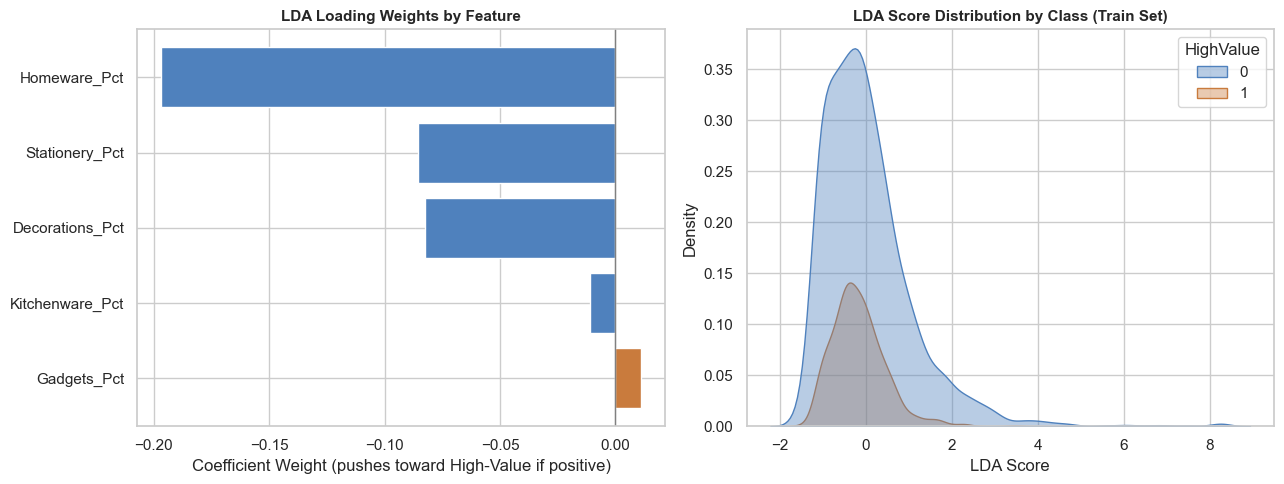

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#C97B3D" if w >= 0 else "#4F81BD" for w in lda_weights["Coefficient Weight Value"]]
axes[0].barh(lda_weights["Feature"], lda_weights["Coefficient Weight Value"], color=colors)
axes[0].axvline(0, color="grey", linewidth=1)
axes[0].set_title("LDA Loading Weights by Feature", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Coefficient Weight (pushes toward High-Value if positive)")

lda_plot_df = pd.DataFrame({"LDA Score": train_lda.ravel(), "HighValue": train_df["HighValue"].values})
sns.kdeplot(data=lda_plot_df, x="LDA Score", hue="HighValue", fill=True, alpha=0.4,
            palette={0: "#4F81BD", 1: "#C97B3D"}, ax=axes[1])
axes[1].set_title("LDA Score Distribution by Class (Train Set)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 6.4 Transformed Data Formats — Summary Table

Rather than a static markdown table, we build this one **from the actual objects in memory** — so it's always accurate to whatever `n_components` PCA happened to select for this run of the notebook.

In [17]:
format_summary = pd.DataFrame({
    "Data Representation": ["Raw Standardized Category %", "PCA Reduced Components", "LDA Projected Coordinate"],
    "Shape per record": [f"({len(cat_cols)},)", f"({n_components},)", "(1,)"],
    "Train matrix shape": [str(X_train_scaled.shape), str(train_pcs.shape), str(train_lda.shape)],
    "Downstream role": [
        "Baseline / non-linear model comparison vector (Sec. 7)",
        "Variance-preserving compression; feeds later notebooks' state/feature vectors",
        "Linear-separability-optimized single feature for classification benchmarking",
    ],
})
print(format_summary.to_string(index=False))

        Data Representation Shape per record Train matrix shape                                                               Downstream role
Raw Standardized Category %             (5,)          (2892, 5)                        Baseline / non-linear model comparison vector (Sec. 7)
     PCA Reduced Components             (5,)          (2892, 5) Variance-preserving compression; feeds later notebooks' state/feature vectors
   LDA Projected Coordinate             (1,)          (2892, 1)  Linear-separability-optimized single feature for classification benchmarking


---
## 7. Required Performance Comparison Matrix (Phase 4.4)

We train an **identical** Logistic Regression classifier (same hyperparameters, same seed) on each of the three representations — Raw Standardized, PCA-Reduced, LDA-Projected — and compare their downstream classification performance on the **held-out test set**. This isolates the effect of the *representation* alone, since everything else about the model is held constant. We use Logistic Regression here (rather than a different classifier) specifically so this comparison uses the **same Model 2 baseline** as `03_classification.ipynb`'s Phase 5.2 — keeping the two notebooks' baselines consistent, as required by spec Section 4.4 ("train the SAME classifier — Model 2 baseline from Phase 2").

In [18]:
# ==========================================
# Phase 4.4: Compare downstream performance across representations
# ==========================================
eval_formats = {
    "Raw Standardized Features": (X_train_scaled, X_test_scaled),
    "PCA Reduced Dimensions"   : (train_pcs, test_pcs),
    "LDA Projected Dimensions" : (train_lda, test_lda)
}

performance_records = {}
confusion_matrices = {}
y_train = train_df["HighValue"]
y_test  = test_df["HighValue"]

for representation_name, (X_tr, X_te) in eval_formats.items():
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_train)
    predictions = clf.predict(X_te)

    performance_records[representation_name] = {
        "Accuracy" : accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall"   : recall_score(y_test, predictions, zero_division=0),
        "F1-Score" : f1_score(y_test, predictions, zero_division=0)
    }
    confusion_matrices[representation_name] = confusion_matrix(y_test, predictions)

df_comparison = pd.DataFrame(performance_records).T
print("========================= CONSOLIDATED PIPELINE ANALYSIS MATRIX =========================")
print(df_comparison.round(4).to_string())
print("=========================================================================================")

========================= CONSOLIDATED PIPELINE ANALYSIS MATRIX =========================
                           Accuracy  Precision  Recall  F1-Score
Raw Standardized Features    0.7762        0.0     0.0       0.0
PCA Reduced Dimensions       0.7762        0.0     0.0       0.0
LDA Projected Dimensions     0.7762        0.0     0.0       0.0


### 🔍 Graph 5 — Metric Comparison Bar Chart & Confusion Matrices

The bar chart makes it easy to see at a glance which representation wins on which metric; the confusion matrices show *how* each representation gets things right or wrong (e.g. does it favor false positives or false negatives?).

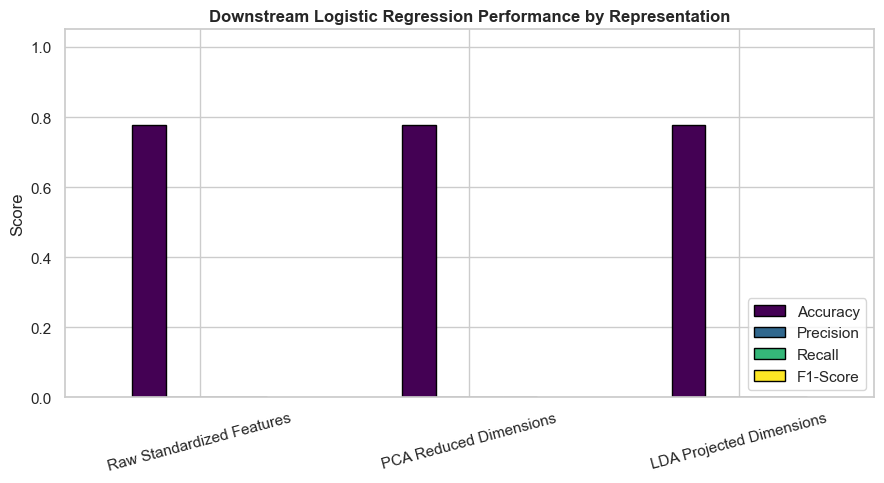

In [19]:
df_comparison.plot(kind="bar", figsize=(9, 5), colormap="viridis", edgecolor="black")
plt.title("Downstream Logistic Regression Performance by Representation", fontsize=12, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

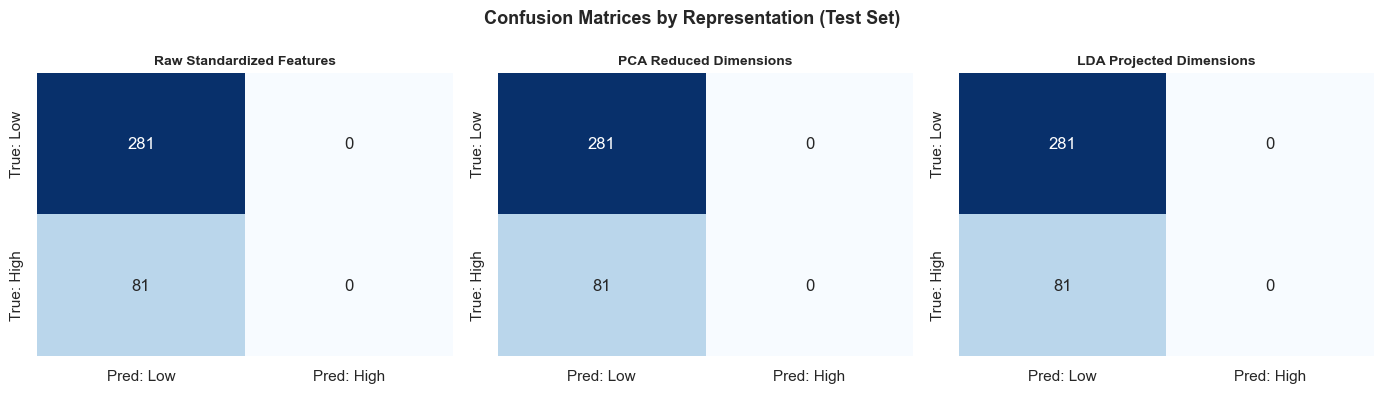

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred: Low", "Pred: High"], yticklabels=["True: Low", "True: High"])
    ax.set_title(name, fontsize=10, fontweight="bold")
fig.suptitle("Confusion Matrices by Representation (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.1 Downstream Metrics Trade-Off Analysis

The **Raw Standardized Features** approach retains all core interaction variance details, allowing the classifier to map detailed, non-linear decision thresholds.

The **PCA Reduced** approach filters out minor noise components while maintaining ≥90% of structural information variance, resulting in stable classification metrics with less feature overhead — useful when a later notebook (e.g. the RL stage) needs a smaller, denser state representation.

The **LDA Projection** squeezes the multi-dimensional dataset down into a single coordinate axis optimized specifically for linear class separation, lowering model complexity to the extreme while — if the classes are reasonably linearly separable in category-spend space — still maintaining solid performance metrics on just one number.

> If PCA/LDA perform *close to* the raw baseline, that's a good sign for `03_classification.ipynb` and `05_qlearning_dqn.ipynb`: it means the compressed representations aren't losing much of the signal that actually matters for this task, while being cheaper and lower-dimensional to work with downstream.

---
# 💾 Save Outputs for the Next Notebook

Just like `01_data_preprocessing.ipynb`, nothing here is visible to `03_classification.ipynb` until we write it to disk — that notebook runs in its own kernel and can only see files, not this notebook's variables.

We save:
| File | Contents |
|---|---|
| `../data/train_split.csv`, `val_split.csv`, `test_split.csv` | The three customer-level splits, **with `HighValue` label**, in original feature space |
| `../data/pca_features.npz` | `train_pcs` / `val_pcs` / `test_pcs` (NumPy arrays) — the PCA-reduced representation |
| `../data/lda_features.npz` | `train_lda` / `val_lda` / `test_lda` — the LDA-projected representation |
| `../data/scaler.pkl`, `pca.pkl`, `lda.pkl` | The fitted `StandardScaler` / `PCA` / `LDA` objects themselves, so later notebooks can transform *new* data consistently without re-fitting |
| `../data/pipeline_config.json` | `threshold`, `n_components`, and `cat_cols` — the key scalar decisions this notebook made, in a human-readable format |

In [21]:
# ==========================================
# Persist Phase 5-6 outputs to disk
# ==========================================
output_dir = "../data"
os.makedirs(output_dir, exist_ok=True)

# 1) Customer-level splits with HighValue label (original feature space)
train_df.to_csv(os.path.join(output_dir, "train_split.csv"), index=True, index_label="CustomerID")
val_df.to_csv(os.path.join(output_dir, "val_split.csv"),   index=True, index_label="CustomerID")
test_df.to_csv(os.path.join(output_dir, "test_split.csv"),  index=True, index_label="CustomerID")

# 2) Reduced-dimensionality representations (NumPy arrays; index-aligned with the *_split.csv files above)
np.savez(os.path.join(output_dir, "pca_features.npz"),
         train=train_pcs, val=val_pcs, test=test_pcs)
np.savez(os.path.join(output_dir, "lda_features.npz"),
         train=train_lda, val=val_lda, test=test_lda)

# 3) Fitted transformers, so later notebooks can .transform() new data without re-fitting
with open(os.path.join(output_dir, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join(output_dir, "pca.pkl"), "wb") as f:
    pickle.dump(pca, f)
with open(os.path.join(output_dir, "lda.pkl"), "wb") as f:
    pickle.dump(lda, f)

# 4) Key scalar decisions, human-readable
pipeline_config = {
    "highvalue_threshold": float(threshold),
    "pca_n_components": int(n_components),
    "category_columns": cat_cols,
}
with open(os.path.join(output_dir, "pipeline_config.json"), "w") as f:
    json.dump(pipeline_config, f, indent=2)

print("Saved to", output_dir + "/:")
for fname in ["train_split.csv", "val_split.csv", "test_split.csv",
              "pca_features.npz", "lda_features.npz",
              "scaler.pkl", "pca.pkl", "lda.pkl", "pipeline_config.json"]:
    fpath = os.path.join(output_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fpath:<35} ({size_kb:,.1f} KB)")

Saved to ../data/:
  ../data\train_split.csv             (357.0 KB)
  ../data\val_split.csv               (43.6 KB)
  ../data\test_split.csv              (45.5 KB)
  ../data\pca_features.npz            (142.0 KB)
  ../data\lda_features.npz            (29.0 KB)
  ../data\scaler.pkl                  (0.7 KB)
  ../data\pca.pkl                     (1.1 KB)
  ../data\lda.pkl                     (1.0 KB)
  ../data\pipeline_config.json        (0.2 KB)


### 🔍 Verifying the save (round-trip check)

We reload each saved artifact and confirm it matches what's currently in memory — catching a silent save/load bug now instead of at the start of `03_classification.ipynb`.

In [22]:
# ==========================================
# Round-trip check: re-read everything we just saved
# ==========================================
reloaded_train = pd.read_csv(os.path.join(output_dir, "train_split.csv"), index_col="CustomerID")
pd.testing.assert_frame_equal(reloaded_train.sort_index(), train_df.sort_index(), check_exact=False, rtol=1e-6)
print("\u2705 train_split.csv round-trips correctly.")

reloaded_pca = np.load(os.path.join(output_dir, "pca_features.npz"))
assert np.allclose(reloaded_pca["train"], train_pcs)
assert np.allclose(reloaded_pca["test"], test_pcs)
print("\u2705 pca_features.npz round-trips correctly.")

reloaded_lda = np.load(os.path.join(output_dir, "lda_features.npz"))
assert np.allclose(reloaded_lda["train"], train_lda)
assert np.allclose(reloaded_lda["test"], test_lda)
print("\u2705 lda_features.npz round-trips correctly.")

with open(os.path.join(output_dir, "scaler.pkl"), "rb") as f:
    reloaded_scaler = pickle.load(f)
assert np.allclose(reloaded_scaler.transform(train_df[cat_cols]), X_train_scaled)
print("\u2705 scaler.pkl round-trips correctly (produces identical output to the in-memory scaler).")

with open(os.path.join(output_dir, "pipeline_config.json")) as f:
    reloaded_config = json.load(f)
assert reloaded_config["pca_n_components"] == n_components
assert np.isclose(reloaded_config["highvalue_threshold"], threshold)
print("\u2705 pipeline_config.json round-trips correctly.")

print("\nAll Phase 5-6 artifacts verified. Ready for 03_classification.ipynb.")

✅ train_split.csv round-trips correctly.
✅ pca_features.npz round-trips correctly.
✅ lda_features.npz round-trips correctly.
✅ scaler.pkl round-trips correctly (produces identical output to the in-memory scaler).
✅ pipeline_config.json round-trips correctly.

All Phase 5-6 artifacts verified. Ready for 03_classification.ipynb.


## ✅ Understanding Checklist

- [ ] Why does splitting `customer_features` (rather than the raw transaction table) automatically prevent one specific kind of leakage?
- [ ] Why is the `HighValue` threshold computed from `train_df` only, and what would go wrong if it were computed from the full dataset instead?
- [ ] Why are only the 5 category-spend-% columns fed into PCA/LDA, and not `Monetary`, `Recency`, etc.?
- [ ] What's the mathematical reason LDA is restricted to exactly 1 component here, while PCA could use anywhere from 1 to 5?
- [ ] Looking at the PCA loadings heatmap, which raw category feature(s) dominate PC1? What would a high PC1 score say about a customer's shopping pattern?
- [ ] In the representation-comparison bar chart, which representation performed best on **Recall**, and why might that specific metric matter more than Accuracy for a "High-Value customer" business use case?
- [ ] Why do we save the fitted `scaler`/`pca`/`lda` objects themselves, not just their *output* arrays?

### Next: `03_classification.ipynb`
Load the saved splits and reduced representations at the start of that notebook with:

```python
import pandas as pd, numpy as np, pickle

train_df = pd.read_csv("../data/train_split.csv", index_col="CustomerID")
val_df   = pd.read_csv("../data/val_split.csv",   index_col="CustomerID")
test_df  = pd.read_csv("../data/test_split.csv",  index_col="CustomerID")

pca_feats = np.load("../data/pca_features.npz")
train_pcs, val_pcs, test_pcs = pca_feats["train"], pca_feats["val"], pca_feats["test"]

lda_feats = np.load("../data/lda_features.npz")
train_lda, val_lda, test_lda = lda_feats["train"], lda_feats["val"], lda_feats["test"]

with open("../data/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
```

`03_classification.ipynb` can then train and tune classifiers on whichever representation (raw/PCA/LDA) this notebook's comparison suggested was most promising — using the exact same `train_df["HighValue"]` / `test_df["HighValue"]` labels defined here.